# Computing Scenarios based on Yearsets

> Based on initial exploration in 0513_distribution-exploration

In [32]:
import numpy as np

RASTER_RESOLUTION = 1000 # in m
N_SAMPLED_YEARS = 100 # in years
INSURANCE_SCALING_FACTORS = np.linspace(0, 1, 11)

## Imports

In [2]:
## So that if you change sth in a src script you don't have to restart the kernel
%load_ext autoreload
%autoreload 2

In [3]:
## Imports
## Allowing for Imports from src folder
import sys
sys.path.append("..") # Adds the project root to the path

In [4]:
## Getting hazard Dict
from src.data_hazard import get_haz_dict

## TODO: Enable Floods!
haz_dict = get_haz_dict()

haz_dict.keys()

dict_keys(['TC', 'TP', 'HL', 'FL'])

In [5]:
from src.data_exposure import get_exposure

hazard_types = list(haz_dict.keys())

# For Merged Hazard
hazard_types.append("MG")

exposure_poly = get_exposure(hazard_types=hazard_types)

exposure_poly_gdf = exposure_poly.gdf

exposure_poly_gdf.head()

,DDEP_C_COD,DDEP_L_LIB,DREG_L_LIB,value,area,insurance,impf_TC,impf_TP,impf_HL,impf_FL,impf_MG,geometry
0,01,Ain,Auvergne-Rhône-Alpes,0.199,5762.4,0.30,1,1,1,1,1,"POLYGON ((6.16845 46.36746, 6.16668 46.37074, ..."
1,02,Aisne,Hauts-de-France,0.532,7361.7,0.32,1,1,1,1,1,"POLYGON ((4.25573 49.90398, 4.23694 49.90378, ..."
2,03,Allier,Auvergne-Rhône-Alpes,0.170,7340.1,0.30,1,1,1,1,1,"POLYGON ((4.00456 46.32748, 3.99436 46.32765, ..."
3,04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur,0.025,6925.2,0.18,1,1,1,1,1,"POLYGON ((6.96709 44.62287, 6.9539 44.63783, 6..."
4,05,Hautes-Alpes,Provence-Alpes-Côte d'Azur,0.017,5548.7,0.18,1,1,1,1,1,"POLYGON ((7.07587 44.68512, 7.07424 44.69209, ..."


---

# Creating Combined Hazard Object

In [6]:
from src.data_exposure import get_exposure
from climada.entity import Exposures
import climada.util.lines_polys_handler as u_lp
from copy import deepcopy

exposure_pnt = u_lp.exp_geom_to_pnt(
    exposure_poly,
    res=RASTER_RESOLUTION,      # TODO: Go back down to KM for Flood and Hail
    to_meters=True,
    disagg_met=u_lp.DisaggMethod.FIX,
    disagg_val=None,
)

## Poly -> Eigen Raster Exposure
exposure_pnt_eigen_gdf = deepcopy(exposure_pnt.gdf)
exposure_pnt_eigen_gdf["value"] = 1
exposure_pnt_eigen = Exposures(exposure_pnt_eigen_gdf)

In [7]:
from climada.engine import ImpactCalc

imp_mat_list= []
freq_list = []

for key, value in haz_dict.items():
    print(f"Computing Impact for {key}")
    
    hazard = value["hazard"]
    impf_set = value["impf_set"]
    
    impact = ImpactCalc(
        exposure_pnt_eigen,
        impfset=impf_set,
        hazard=hazard
    ).impact(save_mat=True)
    
    imp_mat_list.append(
        impact.imp_mat
    )
    
    freq_list.append(
        impact.frequency
    )
    
    haz_dict[key]["impact"] = impact

Computing Impact for TC
Computing Impact for TP
Computing Impact for HL
2026-05-21 13:06:39,431 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.000237 degree for 548477 coordinates.
Computing Impact for FL
2026-05-21 13:11:32,567 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.004492 degree for 14285 coordinates.


In [8]:
from scipy.sparse import vstack
import numpy as np

imp_mat_stacked = vstack(imp_mat_list)

freq_stacked = np.concatenate(freq_list)

In [9]:
from climada.hazard.centroids import Centroids

coords = impact.coord_exp

centroids = Centroids(
    lat=coords[:, 0],
    lon=coords[:, 1]
)

In [10]:
fraction_mat = imp_mat_stacked.copy()
fraction_mat.data[:] = 1.0

In [11]:
from climada.hazard import Hazard

n_events, n_points = imp_mat_stacked.shape

hazard_combined = Hazard(haz_type="MG")

hazard_combined.centroids = centroids

hazard_combined.intensity = imp_mat_stacked
hazard_combined.frequency = freq_stacked
hazard_combined.fraction = fraction_mat

## Adding Infos
hazard_combined.event_id = np.arange(1, n_events + 1)
hazard_combined.event_name = np.array([f"event_{i}" for i in hazard_combined.event_id])
hazard_combined.date = np.arange(n_events).astype("datetime64[D]")


# --- Metadata ---
hazard_combined.units = "rel"
hazard_combined.tag = {
    "description": "Merged Events into Relative Impacts"
}

hazard_combined

## Combined Hazard -> Impact

> via Eigenexposure and Eigenvulnerability

In [12]:
## Defining Eigen Impact Function

from climada.entity import ImpactFunc
from climada.entity.impact_funcs import ImpactFuncSet

impf_eigen = ImpactFunc(
    id=1,
    name = "Total Precipitation Impact Function (ChatGPT)",
    intensity_unit="mm",
    haz_type=hazard_combined.haz_type,
    intensity=np.array([0, 1]),
    mdd=np.array([0, 1]),
    paa = np.ones(2)
)

impf_eigen_set = ImpactFuncSet([impf_eigen])

In [13]:
impact_combined = ImpactCalc(
        exposures=exposure_pnt_eigen,
        impfset=impf_eigen_set,
        hazard=hazard_combined
    ).impact(save_mat=True)

impact_combined

---

# Building and Sampling from Yearsets

Turning Impact into Yearsets allows us to turn the varying types of Hazards into Yearly Impacts at each point in space

In [16]:
## Sampling a Yearset -> Computing Yearly Impacts

import numpy as np
import climada.util.yearsets as yearsets
from climada.engine import Impact

sampled_years = list(range(1, N_SAMPLED_YEARS+1))

# direct computation
yimp, sampling_vect = yearsets.impact_yearset(
    impact_combined, sampled_years, correction_fac=False,
)

2026-05-21 13:30:01,650 - climada.util.yearsets - WARNING - The frequencies of the different events are not equal. This can lead to distorted sampling if the frequencies vary significantly. To avoid this, please set `with_replacement=True` to sample with replacement instead.


In [17]:
## Manually creating imp_mat for Yearset

import scipy.sparse as sp

sparse_matrix = impact_combined.imp_mat
summed_matrix = sp.vstack(
    [
        (
            sp.csr_matrix(1.-(1.-sparse_matrix[indices, :].toarray()).prod(axis=0))
            if len(indices) > 0
            else sp.csr_matrix((1, sparse_matrix.shape[1]))
        )
        for indices in sampling_vect
    ]
)
yimp.imp_mat = summed_matrix

yimp.coord_exp = impact_combined.coord_exp
yimp.at_event, yimp.eai_exp, yimp.aai_agg = (
    ImpactCalc.risk_metrics(yimp.imp_mat, yimp.frequency)
)

In [18]:
## !!! Not actually necessary !!!

## Computing Local Return Periods for Tresholds
from climada.util.plot import plot_from_gdf

threshold_values = [.20, .50]
#gdf_rp, title, cols = yimp.local_return_period(threshold_values, method="extrapolate_constant")

In [19]:
#plot_from_gdf(gdf_rp, title, cols)

---

# Using Yearsets to Infer Payment Distribution

In [20]:
coo = yimp.imp_mat.tocoo()

damage = coo.data
event_idx = coo.row
loc_idx = coo.col

In [21]:
def comp_who_pays_dense(
    insurance_loc
):
    cond_high = damage >= 0.5
    cond_mid  = (damage >= 0.2) & (damage < 0.5)
    cond_low  = damage < 0.2

    F = np.zeros_like(damage)
    I = np.zeros_like(damage)
    G = np.zeros_like(damage)

    # Farmer
    F = (
        cond_high * ((1 - insurance_loc) * 0.65) +
        cond_mid  * ((1 - insurance_loc) * 1.0) +
        cond_low  * 1.0
    )

    # Insurance
    I = (
        cond_high * (insurance_loc * 0.1) +
        cond_mid  * (insurance_loc * 1.0)
    )

    # Government
    G = (
        cond_high * (insurance_loc * 0.9 + (1 - insurance_loc) * 0.35)
    )
    
    return F, I, G

In [33]:
from src.helpers import comp_insurance
from src.helpers import agg_to_departement

exposure_pnt_gdf = exposure_pnt.gdf
insurance_current = exposure_pnt_gdf["insurance"]

final_results = {}
relative_max = 0

for scaling_factor in INSURANCE_SCALING_FACTORS:
    
    scenario_pnt_gdf = deepcopy(exposure_pnt_gdf)
    
    exposure = exposure_pnt.gdf["value"]
    exposure_loc = exposure.iloc[loc_idx].values

    insurance_new = comp_insurance(
        method="coverage",
        insurance_current=insurance_current,
        scaling_factor=scaling_factor
    )
    scenario_pnt_gdf["insurance"] = insurance_new
    insurance_loc = insurance_new.iloc[loc_idx].values
    
    F, I, G = comp_who_pays_dense(insurance_loc)
    
    n_years = yimp.imp_mat.shape[0]

    F_relative = np.bincount(
        loc_idx,
        weights=damage * exposure_loc * F,
        minlength=yimp.imp_mat.shape[1]
    ) / n_years

    I_relative = np.bincount(
        loc_idx,
        weights=damage * exposure_loc * I,
        minlength=yimp.imp_mat.shape[1]
    ) / n_years

    G_relative = np.bincount(
        loc_idx,
        weights=damage * exposure_loc * G,
        minlength=yimp.imp_mat.shape[1]
    ) / n_years
    
    scenario_pnt_gdf["F_relative"] = F_relative
    scenario_pnt_gdf["I_relative"] = I_relative
    scenario_pnt_gdf["G_relative"] = G_relative
    
    scenario_poly = agg_to_departement(
            pnt_gdf=scenario_pnt_gdf,
            value_cols=["value", "insurance", "F_relative", "I_relative", "G_relative"],
            agg_func="mean"
    )
    
    result = scenario_poly[['F_relative', 'I_relative', 'G_relative']].mul(
        scenario_poly['area'], axis=0
    )

    result.columns = ['F_area', 'I_area', 'G_area']

    relative_max = max(relative_max, scenario_poly[['F_relative', 'I_relative', 'G_relative']].max().max())

    scenario_poly = scenario_poly.join(result)

    insured_area = (scenario_poly["insurance"] * scenario_poly["area"]).sum()

    who_pays_what = {
        "F": scenario_poly["F_area"].sum(),
        "I": scenario_poly["I_area"].sum(),
        "G": scenario_poly["G_area"].sum()
    }
    
    
    final_results[scaling_factor] = {
        "scenario_poly": deepcopy(scenario_poly),
        "who_pays_what": deepcopy(who_pays_what),
        "insured_area": deepcopy(insured_area),
    }

for label, scenario in final_results.items():
        scenario["relative_max"] = relative_max  

---

# Visualizing Scenarios

In [34]:
scenarios_dict = final_results

## Plotting Impact

In [35]:
from src.helpers import agg_to_departement

exposure_pnt_gdf["eai"] = yimp.eai_exp

impact_poly_gdf = agg_to_departement(
    exposure_pnt_gdf,
    value_cols=["value", "eai"]
)

impact_poly_gdf["rel_damaged_area"] = impact_poly_gdf["eai"] * impact_poly_gdf["value"]

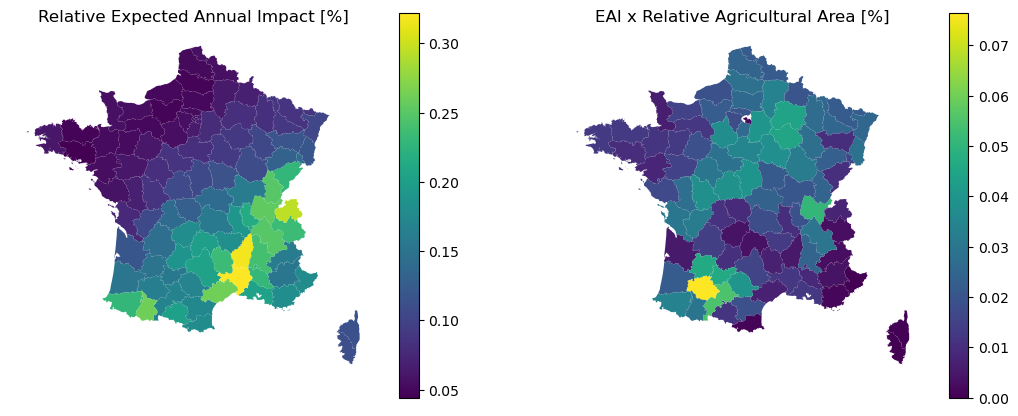

In [36]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2,
                        figsize=(13, 5))

axs[0].set_title("Relative Expected Annual Impact [%]")
impact_poly_gdf.plot(
    column="eai",
    ax=axs[0],
    cmap="viridis",
    legend=True
)

axs[1].set_title("EAI x Relative Agricultural Area [%]")
impact_poly_gdf.plot(
    column="rel_damaged_area",
    ax=axs[1],
    cmap="viridis",
    legend=True,
)

for ax in axs:
    ax.set_axis_off()
    
plt.show()

## Plotting Scenarios Overview

In [37]:
insurance_scaling_factors = []
insured_area = []
who_pays = {"F": [], "I": [], "G": []}

for label, scenario in scenarios_dict.items():
    insurance_scaling_factors.append(label)
    insured_area.append(scenario["insured_area"])
    
    for k in who_pays:
        who_pays[k].append(scenario["who_pays_what"][k])
        
        
total_area = scenarios_dict[0]["scenario_poly"]["area"].sum()

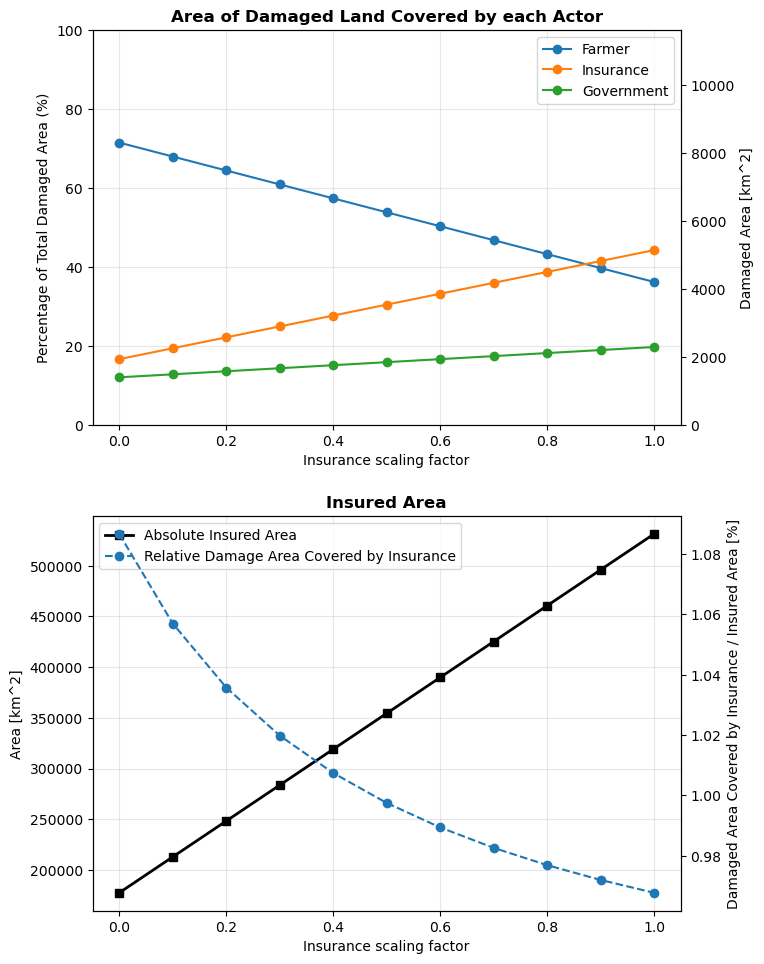

In [38]:
import matplotlib.pyplot as plt
import numpy as np

label_dict = {
    "F": "Farmer",
    "I": "Insurance",
    "G": "Government"
}

# Total damaged area (assuming first index holds totals)
damaged_area_total = who_pays["F"][0] + who_pays["G"][0] + who_pays["I"][0]

fig, axs = plt.subplots(2, 1, figsize=(8, 10),
                        sharex=False)

# --- LEFT PLOT: Who pays What? ---
ax = axs[0]
ax.set_title("Area of Damaged Land Covered by each Actor",
             fontweight="bold")

## Left: Relative Values
ax.set_ylim(0, 100)  # optional but often useful
ax.set_ylabel("Percentage of Total Damaged Area (%)")
ax.set_xlabel("Insurance scaling factor")

## Right: Absolute Values
ax2 = ax.twinx()
ax2.set_ylabel("Damaged Area [km^2]")

for label, values in who_pays.items():
    ax2.plot(
        insurance_scaling_factors,
        values,
        marker="o",
        label=label_dict[label]
    )

ax2.legend()
ax2.set_ylim(0, damaged_area_total)


# --- RIGHT PLOT: Insurance Ratio
ax = axs[1]

# Left: Total Insured Area
ax.set_title("Insured Area", fontweight="bold")
ax.plot(
    insurance_scaling_factors,
    insured_area,
    color="black",
    linewidth=2,
    marker="s",
    label="Absolute Insured Area"
)

ax.set_ylabel("Area [km^2]")
ax.set_xlabel("Insurance scaling factor")

# right: Ratio
relative_insured_area = (np.array(who_pays["I"]) / np.array(insured_area)) * 100

ax_right = ax.twinx()
ax_right.plot(
    insurance_scaling_factors,
    relative_insured_area,
    color="tab:blue",
    linestyle="--",
    marker="o",
    label="Relative Damage Area Covered by Insurance"
)

ax_right.set_ylabel("Damaged Area Covered by Insurance / Insured Area [%]")

# ---- combined legend ----
lines_left, labels_left = ax.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax.legend(lines_left + lines_right, labels_left + labels_right, loc="best")


for ax in axs:
    ax.grid(True, which="both", alpha=0.3)

plt.tight_layout(pad=2.0)
plt.show()

## Plotting Example Scenarios

In [39]:
from src.scenario_helpers import plot_scenario, plot_difference

scenarios_dict.keys()

max_rel_difference = (scenarios_dict[1.0]["scenario_poly"][["F_relative", "I_relative", "G_relative"]]
                      - scenarios_dict[0]["scenario_poly"][["F_relative", "I_relative", "G_relative"]]).max().max()

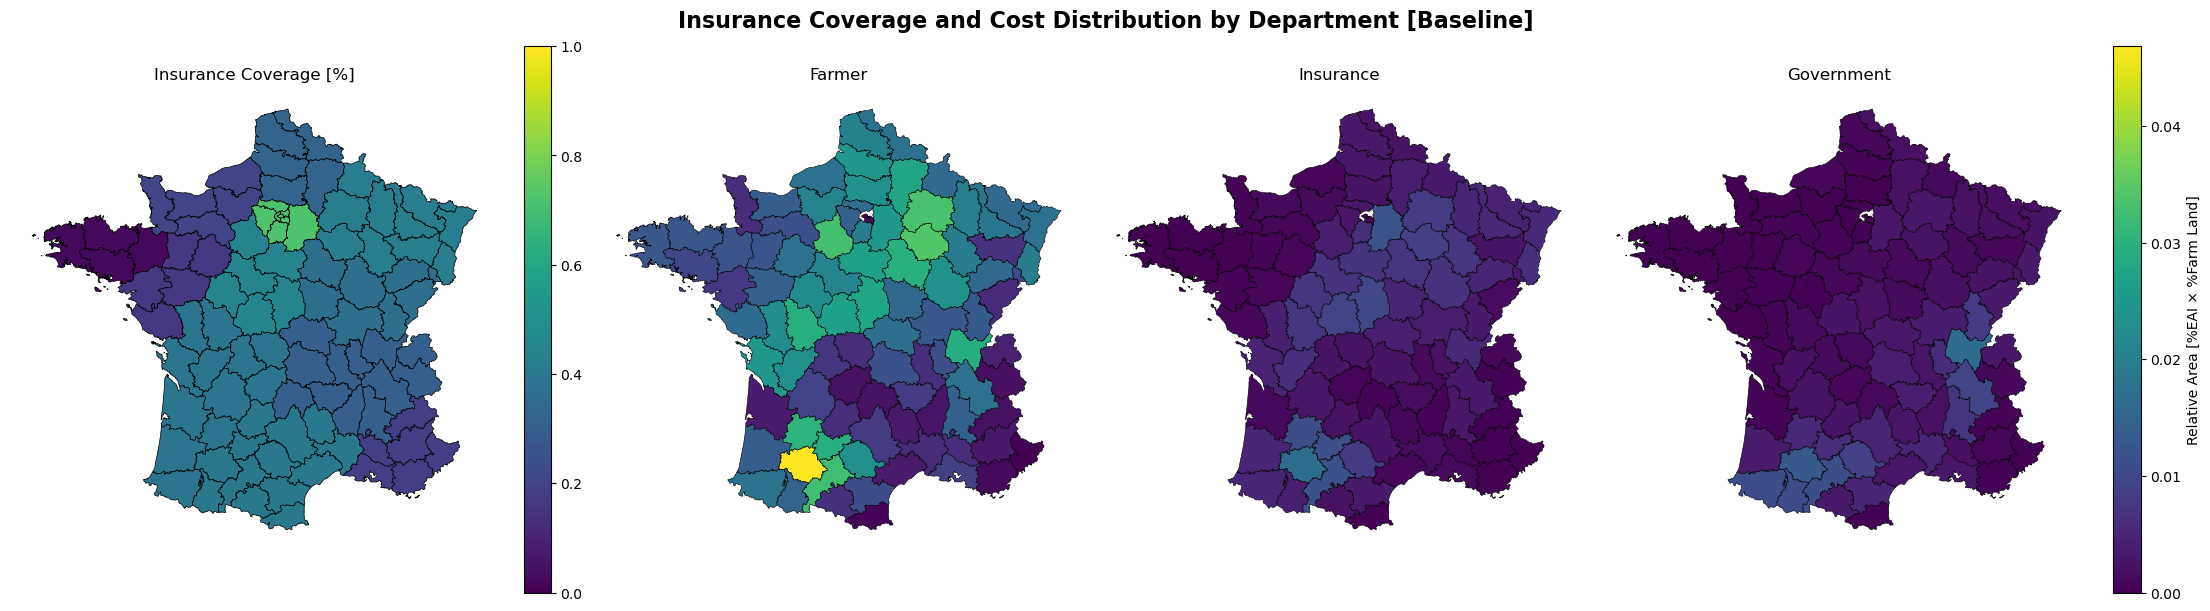

In [40]:
f, axs = plot_scenario(scenarios_dict[0], title_addition="[Baseline]")

plt.show()

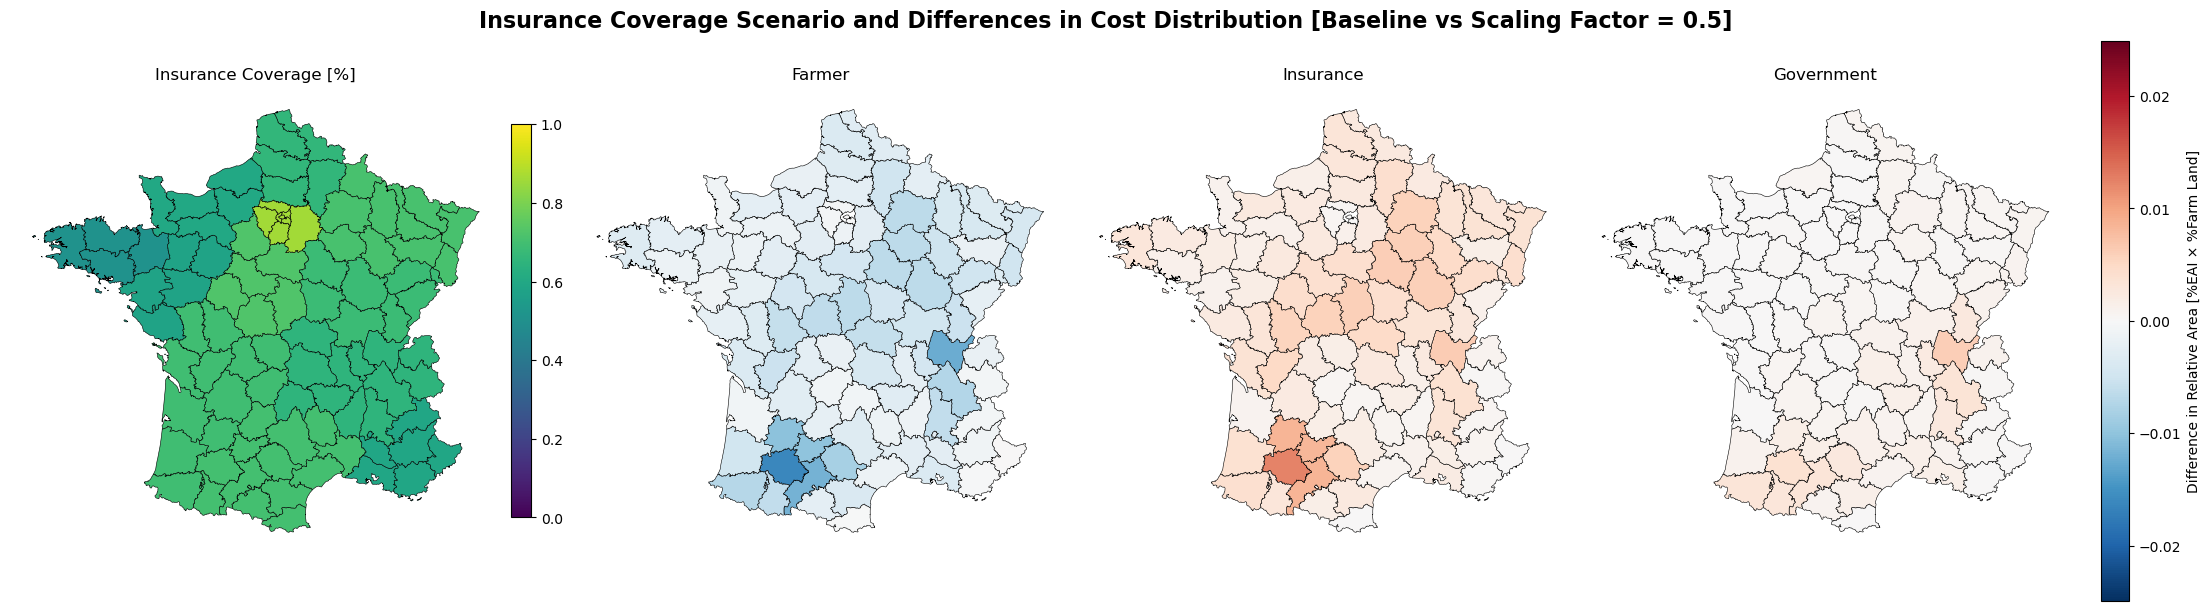

In [41]:
f, axs = plot_difference(scenarios_dict[0], scenarios_dict[0.5],
                         rel_max=max_rel_difference,
                         title_addition="[Baseline vs Scaling Factor = 0.5]")

plt.show()

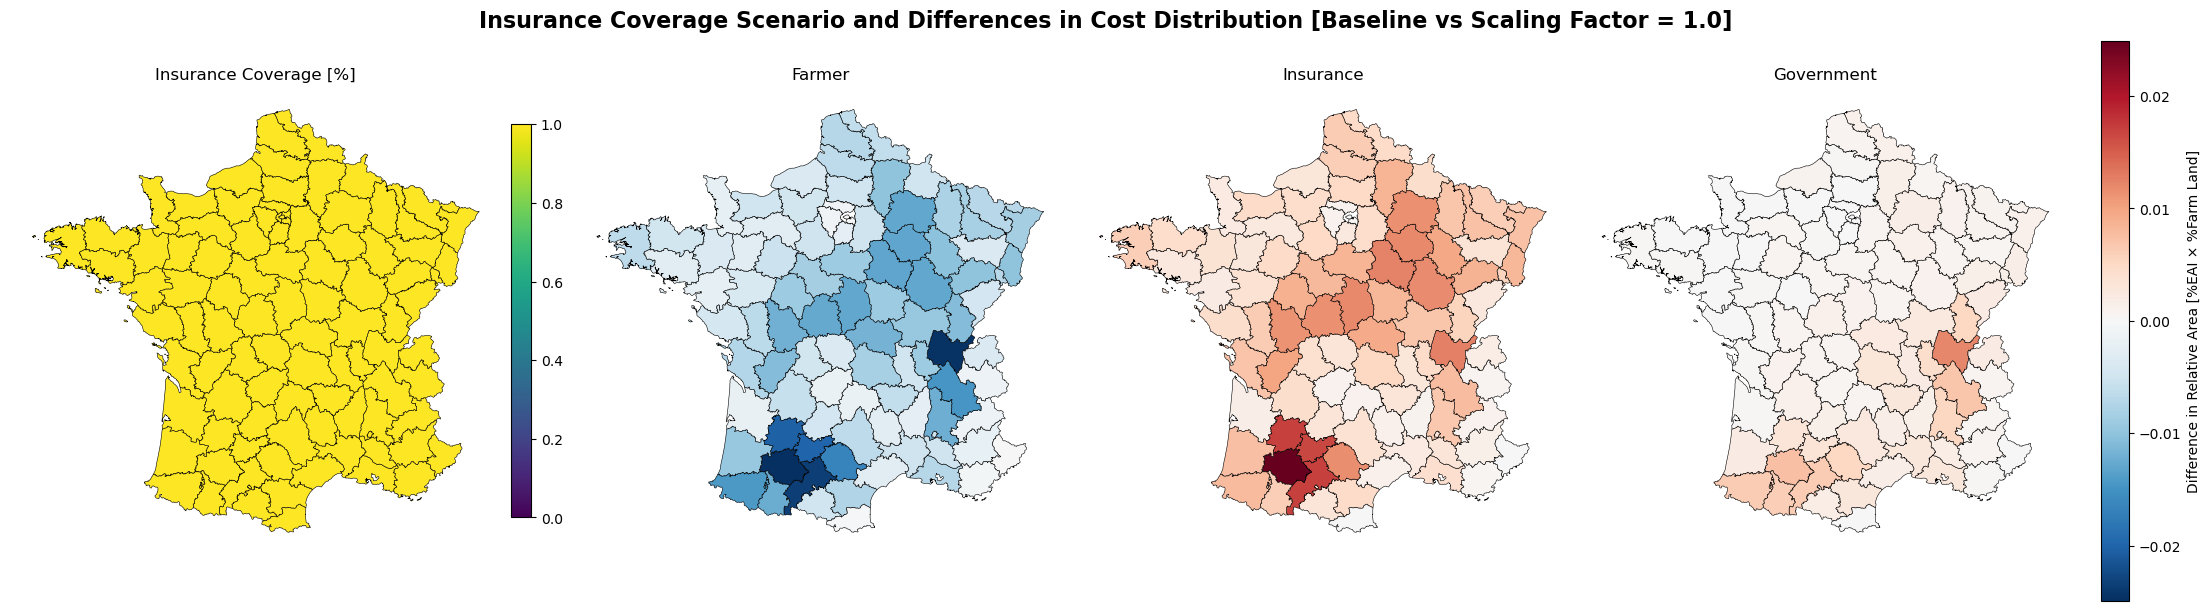

In [42]:
f, axs = plot_difference(scenarios_dict[0], scenarios_dict[1.0],
                         rel_max=max_rel_difference,
                         title_addition="[Baseline vs Scaling Factor = 1.0]")

plt.show()